In [1]:
import nltk
from nltk.corpus import treebank
nltk.download('treebank')
import statistics
import matplotlib.pyplot as plt

# Get sentences, words, and tagged words from the corpus
sentences = treebank.sents()      # List of sentences (each sentence is a list of words)
words = treebank.words()          # List of all words in the corpus
tagged_words = treebank.tagged_words()  # List of tuples (word, POS tag)

[nltk_data] Downloading package treebank to
[nltk_data]     /Users/larsheijnen/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


In [2]:
# Total number of sentences
total_sentences = len(sentences)

# Total number of words
total_words = len(words)

# Sentence lengths
sentence_lengths = [len(s) for s in sentences]

# Variance of sentence lengths
variance_sentence_length = round(statistics.pvariance(sentence_lengths), 3)

# Standard deviation of sentence lengths
std_dev_sentence_length = round(statistics.stdev(sentence_lengths), 3)

# Total number of unique words
unique_words = set(words)
total_unique_words = len(unique_words)

# Average sentence length (words per sentence)
average_sentence_length = round(total_words / total_sentences if total_sentences else 0, 3)

# Extract unique POS tags from the tagged words
unique_pos_tags = {tag for (word, tag) in tagged_words}
num_unique_pos_tags = len(unique_pos_tags)

# Print the statistics
print("Total number of sentences:", total_sentences)
print("Total number of words:", total_words)
print("Total number of unique words:", total_unique_words)
print("Average sentence length:", average_sentence_length)
print("Variance of sentence lengths:", variance_sentence_length)
print("Standard deviation of sentence lengths:", std_dev_sentence_length)
print("Number of unique POS tags:", num_unique_pos_tags)
print("Unique POS tags:", unique_pos_tags)

Total number of sentences: 3914
Total number of words: 100676
Total number of unique words: 12408
Average sentence length: 25.722
Variance of sentence lengths: 165.557
Standard deviation of sentence lengths: 12.869
Number of unique POS tags: 46
Unique POS tags: {'VBZ', 'WDT', '-LRB-', 'JJR', 'POS', 'DT', 'MD', "''", 'NN', 'PRP$', 'VB', '.', 'VBN', 'PRP', 'WP', 'VBP', 'PDT', 'WRB', 'CD', 'NNPS', 'LS', 'JJS', 'VBG', 'NNS', 'UH', 'FW', 'JJ', '-RRB-', 'VBD', 'RP', 'RBR', 'SYM', 'CC', '``', '#', 'WP$', 'IN', 'RB', '$', ':', 'EX', 'RBS', ',', '-NONE-', 'NNP', 'TO'}


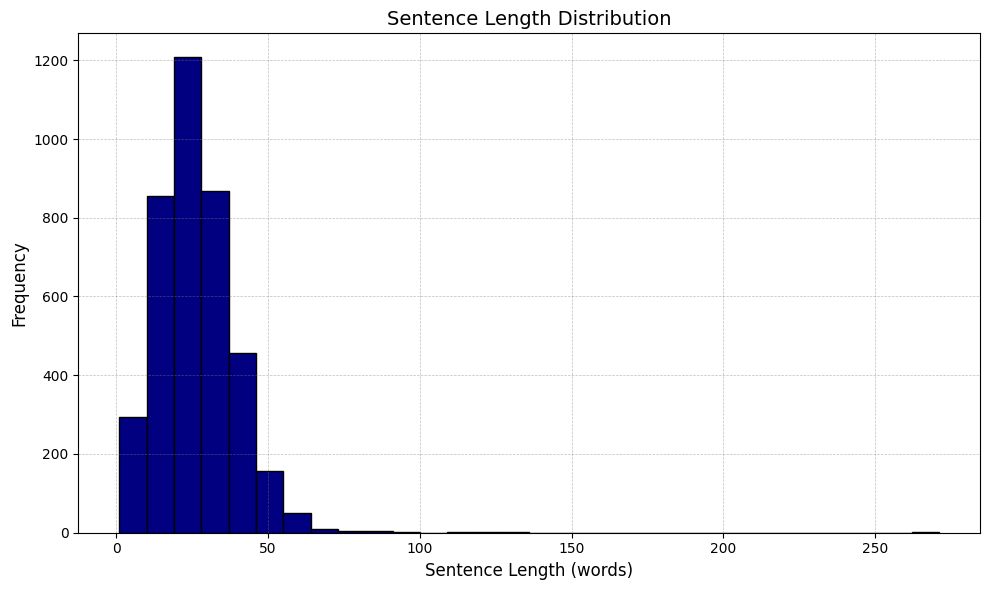

In [3]:
plt.figure(figsize=(10, 6), facecolor='white') 
plt.hist(sentence_lengths, bins=30, color='navy', edgecolor='black')

plt.title("Sentence Length Distribution", color='black', fontsize=14)
plt.xlabel("Sentence Length (words)", color='black', fontsize=12)
plt.ylabel("Frequency", color='black', fontsize=12)

plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')

# Optionally add a grid with lower contrast
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Show or save the plot
plt.tight_layout()
plt.show()


In [4]:
from collections import Counter

# Count the frequency of each word
word_frequencies = Counter(words)

# Get the top 10 most common words
top_10_frequent_words = word_frequencies.most_common(10)

print(f"{'Token':<15}{'Count':<10}")
print("-" * 25)
for word, count in top_10_frequent_words:
    print(f"{word:<15}{count:<10}")


Token          Count     
-------------------------
,              4885      
the            4045      
.              3828      
of             2319      
to             2164      
a              1878      
in             1572      
and            1511      
*-1            1123      
0              1099      


In [5]:
import re

# Define patterns to detect trace tokens and empty categories
TRACE_TOKEN_PATTERN = re.compile(r'^\*.*\*$|^\*$|^\*-?\d+$|^0$')

def is_valid_token(word, pos_tag=None):
    """
    Returns True if the token is a real word and not a syntactic trace or Treebank placeholder.
    """
    if pos_tag == '-NONE-':
        return False
    if TRACE_TOKEN_PATTERN.match(word):
        return False
    return True

# --- Create cleaned sentences as strings (ready for BERT) ---
cleaned_sentences = []
for sentence in treebank.tagged_sents():
    cleaned_tokens = [word for word, pos in sentence if is_valid_token(word, pos)]
    if cleaned_tokens:  # Skip if the result is empty
        cleaned_sentences.append(" ".join(cleaned_tokens))

# --- Optional: Token list version (if needed for manual token handling) ---
cleaned_token_lists = []
for sentence in treebank.tagged_sents():
    cleaned_tokens = [word for word, pos in sentence if is_valid_token(word, pos)]
    if cleaned_tokens:
        cleaned_token_lists.append(cleaned_tokens)

# --- Example Output ---
print("Original:", " ".join(word for word, _ in treebank.tagged_sents()[18]))
print("Cleaned :", cleaned_sentences[18])

Original: `` The morbidity rate is a striking finding among those of us who *T*-5 study asbestos-related diseases , '' said *T*-1 Dr. Talcott .
Cleaned : `` The morbidity rate is a striking finding among those of us who study asbestos-related diseases , '' said Dr. Talcott .


In [7]:
# Gather statistics on the cleaned data
cleaned_total_sentences = len(cleaned_sentences)
cleaned_all_tokens = [token for sentence_tokens in cleaned_token_lists for token in sentence_tokens]
cleaned_total_tokens = len(cleaned_all_tokens)
cleaned_unique_tokens = set(cleaned_all_tokens)
cleaned_total_unique_tokens = len(cleaned_unique_tokens)

# Sentence length statistics
cleaned_sentence_lengths = [len(sentence_tokens) for sentence_tokens in cleaned_token_lists]
if len(cleaned_sentence_lengths) > 1:
    cleaned_variance_sentence_length = round(statistics.pvariance(cleaned_sentence_lengths), 3)
    cleaned_std_dev_sentence_length = round(statistics.stdev(cleaned_sentence_lengths), 3)
else:
    cleaned_variance_sentence_length = 0
    cleaned_std_dev_sentence_length = 0

# Average sentence length
cleaned_average_sentence_length = round(cleaned_total_tokens / cleaned_total_sentences if cleaned_total_sentences else 0, 3)

# Extract cleaned POS tags
cleaned_tagged_tokens = []
for sentence in treebank.tagged_sents():
    cleaned_tagged_tokens.extend([(word, pos) for word, pos in sentence if is_valid_token(word, pos)])
cleaned_unique_pos_tags = {tag for (word, tag) in cleaned_tagged_tokens}
cleaned_num_unique_pos_tags = len(cleaned_unique_pos_tags)

# Print the statistics
print("\n--- Statistics for Cleaned Data ---")
print("Total number of sentences:", cleaned_total_sentences)
print("Total number of words:", cleaned_total_tokens)
print("Total number of unique words:", cleaned_total_unique_tokens)
print("Average sentence length:", cleaned_average_sentence_length)
print("Variance of sentence lengths:", cleaned_variance_sentence_length)
print("Standard deviation of sentence lengths:", cleaned_std_dev_sentence_length)
print("Number of unique POS tags:", cleaned_num_unique_pos_tags)
print("Unique POS tags:", cleaned_unique_pos_tags)

# Print comparison with original data
print("\n--- Comparison with Original Data ---")
print(f"Sentences removed: {total_sentences - cleaned_total_sentences}")
print(f"Words removed: {total_words - cleaned_total_tokens}")
print(f"Unique words removed: {total_unique_words - cleaned_total_unique_tokens}")
print(f"Change in average sentence length: {cleaned_average_sentence_length - average_sentence_length:.3f}")
print(f"Change in sentence length variance: {cleaned_variance_sentence_length - variance_sentence_length:.3f}")
print(f"POS tags removed: {num_unique_pos_tags - cleaned_num_unique_pos_tags}")

# Most frequent tokens in cleaned data
from collections import Counter
cleaned_word_frequencies = Counter(cleaned_all_tokens)
cleaned_top_10_frequent_words = cleaned_word_frequencies.most_common(10)

print("\n--- Most Frequent Tokens in Cleaned Data ---")
print(f"{'Token':<15}{'Count':<10}")
print("-" * 25)
for word, count in cleaned_top_10_frequent_words:
    print(f"{word:<15}{count:<10}")


--- Statistics for Cleaned Data ---
Total number of sentences: 3914
Total number of words: 94084
Total number of unique words: 11968
Average sentence length: 24.038
Variance of sentence lengths: 140.696
Standard deviation of sentence lengths: 11.863
Number of unique POS tags: 45
Unique POS tags: {'VBZ', 'WDT', '-LRB-', 'JJR', 'POS', 'DT', 'MD', "''", 'NN', 'PRP$', 'VB', '.', 'VBN', 'PRP', 'WP', 'VBP', 'PDT', 'WRB', 'CD', 'NNPS', 'LS', 'JJS', 'VBG', 'NNS', 'UH', 'FW', 'JJ', '-RRB-', 'VBD', 'RP', 'RBR', 'SYM', 'CC', '``', '#', 'WP$', 'IN', 'RB', '$', ':', 'EX', 'RBS', ',', 'NNP', 'TO'}

--- Comparison with Original Data ---
Sentences removed: 0
Words removed: 6592
Unique words removed: 440
Change in average sentence length: -1.684
Change in sentence length variance: -24.861
POS tags removed: 1

--- Most Frequent Tokens in Cleaned Data ---
Token          Count     
-------------------------
,              4885      
the            4045      
.              3828      
of             2319 

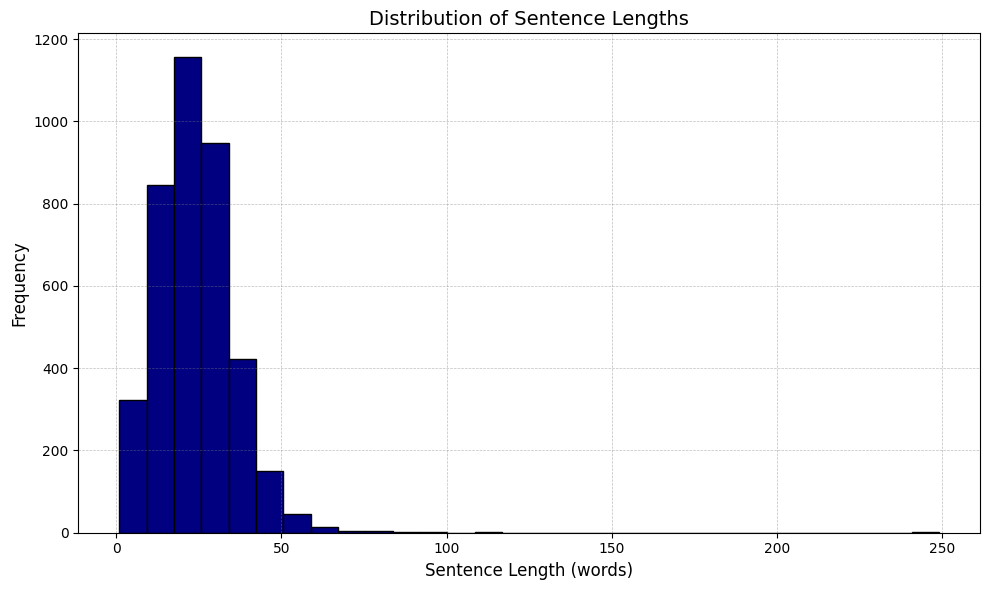

In [11]:
plt.figure(figsize=(10, 6), facecolor='white') 
plt.hist(cleaned_sentence_lengths, bins=30, color='navy', edgecolor='black')

plt.title("Distribution of Sentence Lengths", color='black', fontsize=14)
plt.xlabel("Sentence Length (words)", color='black', fontsize=12)
plt.ylabel("Frequency", color='black', fontsize=12)

plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')

# Optionally add a grid with lower contrast
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Show or save the plot
plt.tight_layout()
plt.show()


In [13]:
# Define a threshold for identifying outliers (e.g., sentences longer than mean + 3 * std_dev)
outlier_threshold = cleaned_average_sentence_length + 3 * cleaned_std_dev_sentence_length

# Identify outlier sentences
outlier_sentences = [(i, sentence, len(sentence.split())) for i, sentence in enumerate(cleaned_sentences) if len(sentence.split()) > outlier_threshold]

# Check for data errors and assess their frequency and context
print(f"Outlier Threshold: {outlier_threshold} words")
print(f"Number of Outlier Sentences: {len(outlier_sentences)}\n")


# Sort the outlier sentences by their length in descending order
outlier_sentences_sorted = sorted(outlier_sentences, key=lambda x: x[2], reverse=True)

# Display the sorted outlier sentences
print("\n--- Outlier Sentences Sorted by Length ---")
for idx, sentence, length in outlier_sentences_sorted:
    print(f"Index: {idx}, Length: {length}")
    print(f"Sentence: {sentence}\n")

Outlier Threshold: 59.626999999999995 words
Number of Outlier Sentences: 24


--- Outlier Sentences Sorted by Length ---
Index: 1854, Length: 249
Sentence: The following were barred or , where noted , suspended and consented to findings without admitting or denying wrongdoing : Edward L. Cole , Jackson , Miss. , $ 10,000 fine ; Rita Rae Cross , Denver , $ 2,500 fine and 30-day suspension ; Thomas Richard Meinders , Colorado Springs , Colo. , $ 2,000 fine , five-day suspension and eight-month suspension as a principal ; Ronald A. Cutrer , Baton Rouge , La. , $ 15,000 fine and one-month suspension ; Karl Grant Hale , Midvale , Utah , $ 15,000 fine ; Clinton P. Hayne , New Orleans , $ 7,500 fine and one-week suspension ; Richard M. Kane , Coconut Creek , Fla. , $ 250,000 fine ; John B. Merrick , Aurora , Colo. , $ 1,000 fine and 10-day suspension ; John P. Miller , Baton Rouge , $ 2,000 fine and two-week suspension ; Randolph K. Pace , New York , $ 10,000 fine and 90-day suspension ; Bria